# Feature Information Studies

Study the marginal value of adding **x3** under two controlled regimes.

| Setup | Features |
|-------|----------|
| setup_1 | {x1, x2} |
| setup_2 | {x1, x2, x3} |

**Improvement** = score(setup_2) − score(setup_1) for higher-is-better metrics (AUC, AP).  
For logloss: improvement = logloss(setup_1) − logloss(setup_2).

**Study A** — class-balance sensitivity: fixed I(x1), I(x2), I(x3); vary positive fraction `p_pos`.  
**Study B** — new-feature information sensitivity: fixed `p_pos`; vary I(x3).

Information proxy (Gaussian DGP): `info_j = |μ₁ⱼ − μ₀ⱼ| / σ`

## Setup

In [12]:
# pip install numpy pandas scikit-learn matplotlib

from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
# dark style
plt.style.use("dark_background")
import numpy as np
import pandas as pd
from rich import print

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 5)

## 0. Config

Import the default config from the script. Override keys here before running studies.

In [ ]:
from feature_information_studies import CONFIG

# Notebook override: denser grid at low positive rates
CONFIG["study_A_positive_fraction"]["p_pos_grid"] = [
    0.001, 0.005, 0.01, 0.015, 0.02, 0.03, 0.05, 0.075, 0.10, 0.15, 0.25, 0.40, 0.50,
]

# Larger samples so rare p_pos cells still get enough positives
# e.g. p_pos=0.001 -> ~200 positives at train=200_000
CONFIG["sample_sizes"] = {
    "train": 200_000,
    "valid": 10_000,
    "test": 40_000,
}

CONFIG["primary_metric"] = "average_precision"
CONFIG["model"]["backend"] = "catboost"
# CONFIG["test_sampling"]["n_repeats"] = 5  # faster smoke test

print(json.dumps(CONFIG, indent=2))

{
  "output_dir": "artifacts_info_studies",
  "target_col": "y",
  "primary_metric": "average_precision",
  "model": {
    "backend": "hgb",
    "random_state": 42,
    "iterations": 60,
    "learning_rate": 0.06,
    "max_leaf_nodes": 16
  },
  "sample_sizes": {
    "train": 2000,
    "valid": 500,
    "test": 2000
  },
  "seeds": {
    "train": 101,
    "valid": 202,
    "test_base": 10000
  },
  "test_sampling": {
    "n_repeats": 20
  },
  "setups": {
    "setup_1_x1_x2": [
      "x1",
      "x2"
    ],
    "setup_2_x1_x2_x3": [
      "x1",
      "x2",
      "x3"
    ]
  },
  "study_A_positive_fraction": {
    "p_pos_grid": [
      0.005,
      0.01,
      0.015,
      0.02,
      0.03,
      0.05,
      0.075,
      0.1,
      0.15,
      0.25,
      0.4,
      0.5
    ],
    "sigma": 1.0,
    "fixed_info": {
      "x1": 0.85,
      "x2": 0.55,
      "x3": 0.35
    }
  },
  "study_B_x3_information": {
    "p_pos": 0.15,
    "sigma": 1.0,
    "fixed_info": {
      "x1": 0.85,
      "x2": 0.55
    },
    "x3_info_grid": [
      0.0,
      0.1,
      0.2,
      0.35,
      0.5,
      0.75,
      1.0,
      1.25
    ]
  }
}

## 1. Data generator

`GaussianBinaryDGP` samples binary labels and Gaussian features:

- y ~ Bernoulli(p_pos)
- x_j | y=0 ~ N(0, σ)
- x_j | y=1 ~ N(info_j · σ, σ)

In [29]:
from feature_information_studies import GaussianBinaryDGP

demo_dgp = GaussianBinaryDGP(
    p_pos=0.15,
    info={"x1": 0.85, "x2": 0.55, "x3": 0.35},
    sigma=1.0,
)
demo_df = demo_dgp.sample(n=5, seed=42)
demo_df

,y,x1,x2,x3
0,0,-1.302180,0.879398,-0.859292
1,0,0.127840,0.777792,0.368751
2,1,0.533757,0.616031,-0.608883
3,0,-0.016801,1.127241,0.878450
4,0,-0.853044,0.467509,-0.049926


## 1b. EDA

Explore synthetic data before running the full studies. We use the **Study B baseline** settings (`p_pos = 0.15`, fixed info for x1/x2/x3) and sample at the configured train size.

In [30]:
study_b_cfg = CONFIG["study_B_x3_information"]
eda_info = {
    **study_b_cfg["fixed_info"],
    "x3": study_b_cfg["x3_info_grid"][3],  # default mid-grid: 0.35
}

eda_dgp = GaussianBinaryDGP(
    p_pos=study_b_cfg["p_pos"],
    info=eda_info,
    sigma=study_b_cfg["sigma"],
)
eda_n = CONFIG["sample_sizes"]["train"]
eda_df = eda_dgp.sample(n=eda_n, seed=CONFIG["seeds"]["train"])

eda_df.head(10)

,y,x1,x2,x3
0,1,1.697756,1.318765,1.708695
1,0,-1.029880,1.033782,1.214375
2,0,0.254975,-1.668411,-0.922336
3,0,0.261789,-0.631342,0.415467
4,0,1.156561,-0.212648,0.270261
5,1,1.244721,1.497160,2.125039
6,1,1.716865,0.782129,-1.912438
7,0,0.980953,1.014448,-0.184578
8,1,2.082180,1.581588,-0.611737
9,0,-0.709918,-2.205617,-0.712096


In [31]:
class_counts = eda_df["y"].value_counts().sort_index()
empirical_p_pos = class_counts.get(1, 0) / len(eda_df)

summary = pd.DataFrame(
    {
        "n": class_counts,
        "share": class_counts / len(eda_df),
    },
    index=["y=0", "y=1"],
)
summary.index.name = "class"

print(f"Target p_pos (DGP): {study_b_cfg['p_pos']:.2f}")
print(f"Empirical p_pos:      {empirical_p_pos:.3f}")
print(f"Sample size:          {eda_n:,}")
display(summary)

feature_cols = ["x1", "x2", "x3"]
display(
    eda_df.groupby("y")[feature_cols]
    .agg(["mean", "std"])
    .round(3)
)

Target p_pos (DGP): 0.15

Empirical p_pos:      0.144

Sample size:          2,000

,n,share
class,,
y=0,NaN,NaN
y=1,NaN,NaN


x1            x2            x3       
    mean    std   mean    std   mean    std
y                                          
0 -0.007  0.989 -0.000  1.004  0.026  0.996
1  0.859  1.064  0.606  1.011  0.294  1.074

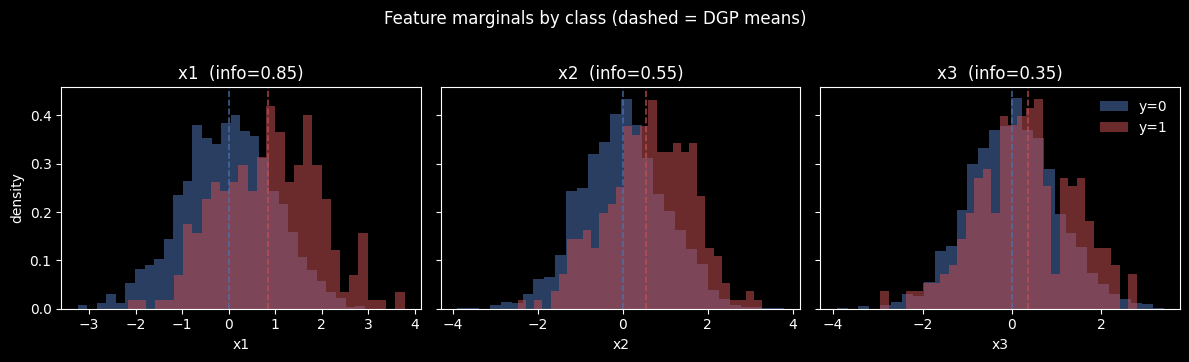

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)

for ax, col in zip(axes, feature_cols):
    info_j = eda_info[col]
    for y_val, color, label in [(0, "#4C72B0", "y=0"), (1, "#C44E52", "y=1")]:
        subset = eda_df.loc[eda_df["y"] == y_val, col]
        ax.hist(subset, bins=30, alpha=0.55, density=True, color=color, label=label)

    ax.axvline(0.0, color="#4C72B0", linestyle="--", linewidth=1.2, alpha=0.8)
    ax.axvline(info_j * study_b_cfg["sigma"], color="#C44E52", linestyle="--", linewidth=1.2, alpha=0.8)
    ax.set_title(f"{col}  (info={info_j})")
    ax.set_xlabel(col)

axes[0].set_ylabel("density")
axes[-1].legend(frameon=False)
fig.suptitle("Feature marginals by class (dashed = DGP means)", y=1.02)
fig.tight_layout()
plt.show()

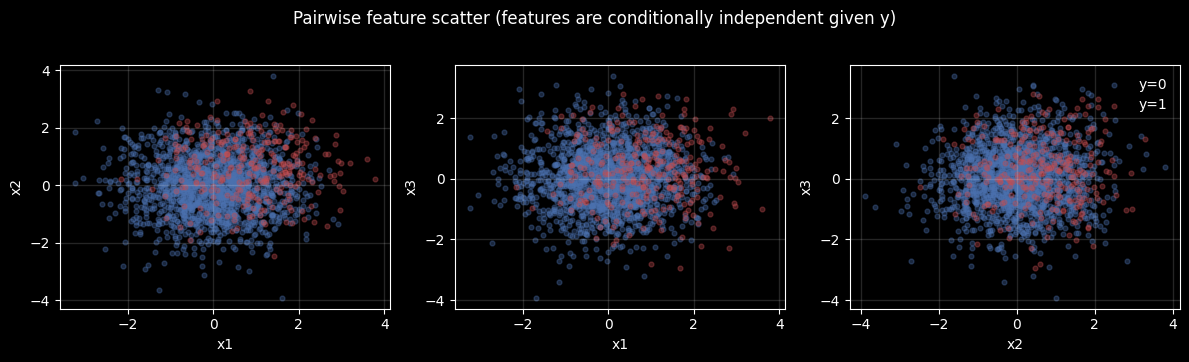

,x1,x2,x3
x1,1.000,0.050,0.041
x2,0.050,1.000,0.039
x3,0.041,0.039,1.000


In [33]:
pairs = [("x1", "x2"), ("x1", "x3"), ("x2", "x3")]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for ax, (x_col, y_col) in zip(axes, pairs):
    for y_val, color, label in [(0, "#4C72B0", "y=0"), (1, "#C44E52", "y=1")]:
        mask = eda_df["y"] == y_val
        ax.scatter(
            eda_df.loc[mask, x_col],
            eda_df.loc[mask, y_col],
            s=12,
            alpha=0.35,
            c=color,
            label=label,
        )

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.grid(True, linewidth=1, alpha=0.15)

axes[-1].legend(frameon=False, loc="upper right")
fig.suptitle("Pairwise feature scatter (features are conditionally independent given y)", y=1.02)
fig.tight_layout()
plt.show()

display(eda_df[feature_cols].corr().round(3))

### Study knobs preview

How the two experimental sweeps change the data **before** model training.

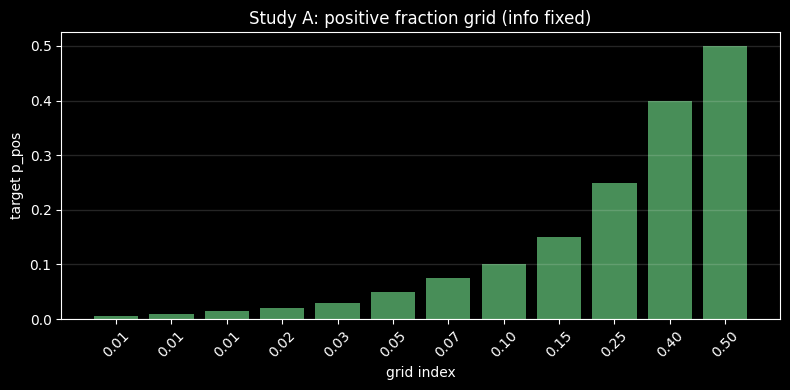

In [34]:
# Study A: class balance sweep at fixed information
study_a_cfg = CONFIG["study_A_positive_fraction"]
p_pos_grid = study_a_cfg["p_pos_grid"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    range(len(p_pos_grid)),
    p_pos_grid,
    color="#55A868",
    alpha=0.85,
)
ax.set_xticks(range(len(p_pos_grid)))
ax.set_xticklabels([f"{p:.2f}" for p in p_pos_grid], rotation=45)
ax.set_xlabel("grid index")
ax.set_ylabel("target p_pos")
ax.set_title("Study A: positive fraction grid (info fixed)")
ax.grid(True, axis="y", linewidth=1, alpha=0.15)
fig.tight_layout()
plt.show()

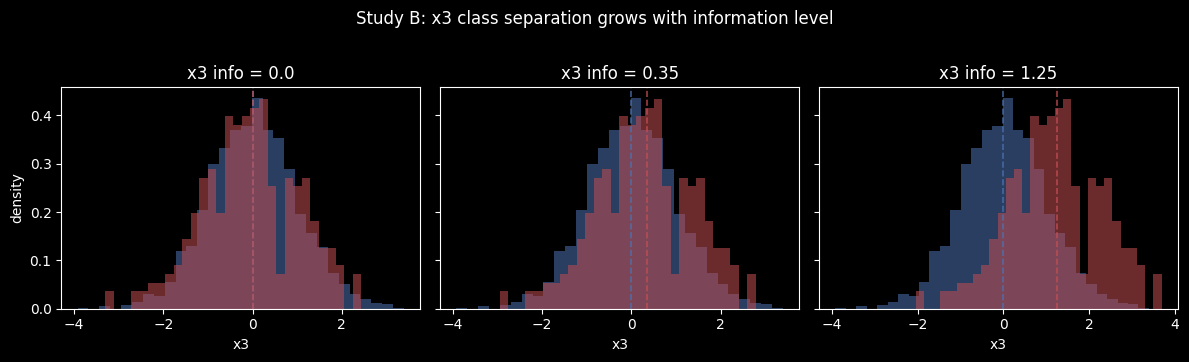

In [35]:
# Study B: x3 information sweep at fixed p_pos
x3_info_grid = study_b_cfg["x3_info_grid"]
preview_levels = [x3_info_grid[0], x3_info_grid[3], x3_info_grid[-1]]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)

for ax, x3_info in zip(axes, preview_levels):
    preview_dgp = GaussianBinaryDGP(
        p_pos=study_b_cfg["p_pos"],
        info={**study_b_cfg["fixed_info"], "x3": x3_info},
        sigma=study_b_cfg["sigma"],
    )
    preview_df = preview_dgp.sample(n=eda_n, seed=CONFIG["seeds"]["train"])

    for y_val, color in [(0, "#4C72B0"), (1, "#C44E52")]:
        ax.hist(
            preview_df.loc[preview_df["y"] == y_val, "x3"],
            bins=30,
            alpha=0.55,
            density=True,
            color=color,
        )

    ax.axvline(0.0, color="#4C72B0", linestyle="--", linewidth=1.2, alpha=0.8)
    ax.axvline(x3_info * study_b_cfg["sigma"], color="#C44E52", linestyle="--", linewidth=1.2, alpha=0.8)
    ax.set_title(f"x3 info = {x3_info}")
    ax.set_xlabel("x3")

axes[0].set_ylabel("density")
fig.suptitle("Study B: x3 class separation grows with information level", y=1.02)
fig.tight_layout()
plt.show()

## 2. Model factory

Same model backend for both setups; only the feature set changes.

In [36]:
from feature_information_studies import ModelFactory

factory = ModelFactory(CONFIG["model"])
model = factory.create()
type(model).__name__

'HistGradientBoostingClassifier'

## 3. Evaluation engine

`SetupComparator` trains setup_1 and setup_2 on fixed train/valid data, then scores repeated fresh test samples and computes improvement.

In [37]:
from feature_information_studies import SetupComparator

comparator = SetupComparator(
    setups=CONFIG["setups"],
    target_col=CONFIG["target_col"],
    primary_metric=CONFIG["primary_metric"],
    model_factory=factory,
)
comparator.setups

{'setup_1_x1_x2': ['x1', 'x2'], 'setup_2_x1_x2_x3': ['x1', 'x2', 'x3']}

## 4. Study runner

Orchestrates both studies, writes CSV artifacts, and produces summary plots.

In [38]:
from feature_information_studies import InformationStudyRunner

runner = InformationStudyRunner(CONFIG)
runner.save_config()
print(f"Output dir: {runner.output_dir}")

Output dir: artifacts_info_studies

In [39]:
def plot_study_summary_inline(
    summary: pd.DataFrame,
    x_col: str,
    title: str,
    primary_metric: str,
) -> None:
    fig, ax = plt.subplots(figsize=(9, 5))

    x = summary["condition_value"].values
    y = summary["mean_improvement"].values
    err = summary["std_improvement"].fillna(0).values

    ax.axhline(0, linewidth=2, alpha=0.35)
    ax.plot(x, y, marker="o", linewidth=3)
    ax.fill_between(x, y - err, y + err, alpha=0.18)

    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel(f"Mean improvement in {primary_metric.upper()}")
    ax.grid(True, linewidth=2, alpha=0.1)
    ax.spines[["top", "right"]].set_visible(False)

    fig.tight_layout()
    plt.show()

## 5. Study A — varying positive fraction

Fixed feature information; sweep `p_pos`.

,condition_name,condition_value,mean_improvement,std_improvement,p_improvement_gt_0,mean_baseline_score,mean_challenger_score,n_repeats
0,p_pos,0.005,0.00641,0.01196,0.65,0.00968,0.01609,20
1,p_pos,0.010,-0.00045,0.01800,0.70,0.02910,0.02866,20
2,p_pos,0.015,0.00311,0.00675,0.70,0.03643,0.03954,20
3,p_pos,0.020,-0.00220,0.01847,0.50,0.05353,0.05133,20
4,p_pos,0.030,0.00009,0.01625,0.50,0.07148,0.07157,20
5,p_pos,0.050,0.00930,0.01434,0.80,0.11979,0.12909,20
6,p_pos,0.075,0.01339,0.01100,1.00,0.20146,0.21485,20
7,p_pos,0.100,0.00783,0.00827,0.80,0.25396,0.26179,20
8,p_pos,0.150,0.00784,0.01284,0.70,0.35885,0.36669,20
9,p_pos,0.250,0.01775,0.01308,0.90,0.51173,0.52948,20


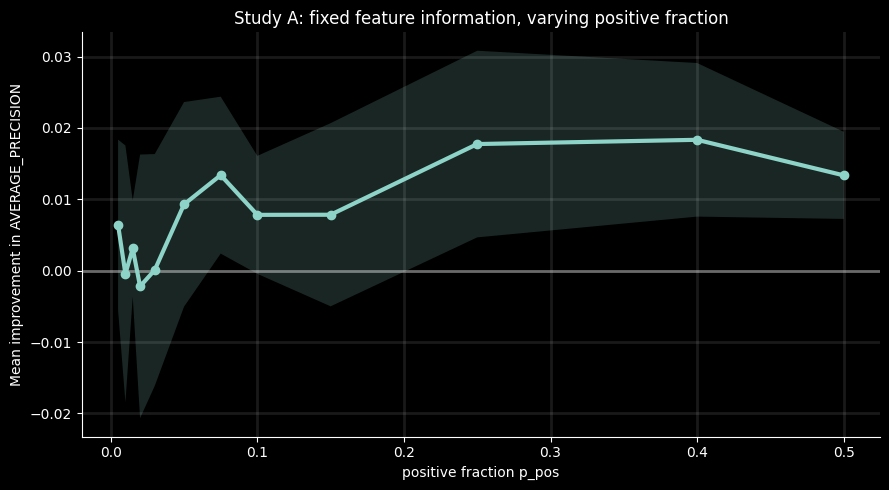

In [40]:
study_A_improvements, study_A_summary = runner.run_study_A_positive_fraction()

display(study_A_summary.round(5))

plot_study_summary_inline(
    summary=study_A_summary,
    x_col="positive fraction p_pos",
    title="Study A: fixed feature information, varying positive fraction",
    primary_metric=CONFIG["primary_metric"],
)

runner.plot_study_summary(
    summary=study_A_summary,
    x_col="positive fraction p_pos",
    title="Study A: fixed feature information, varying positive fraction",
    filename="study_A_positive_fraction.png",
)

## 6. Study B — varying x3 information

Fixed positive fraction; sweep I(x3).

,condition_name,condition_value,mean_improvement,std_improvement,p_improvement_gt_0,mean_baseline_score,mean_challenger_score,n_repeats
0,x3_info,0.00,-0.00047,0.01152,0.45,0.35816,0.35769,20
1,x3_info,0.10,0.00658,0.01324,0.65,0.34852,0.35510,20
2,x3_info,0.20,-0.00241,0.01039,0.30,0.34750,0.34509,20
3,x3_info,0.35,0.01746,0.01238,0.95,0.35057,0.36804,20
4,x3_info,0.50,0.03308,0.01647,1.00,0.36035,0.39343,20
5,x3_info,0.75,0.09062,0.02125,1.00,0.35404,0.44466,20
6,x3_info,1.00,0.14163,0.01852,1.00,0.35061,0.49223,20
7,x3_info,1.25,0.21642,0.02828,1.00,0.35880,0.57521,20


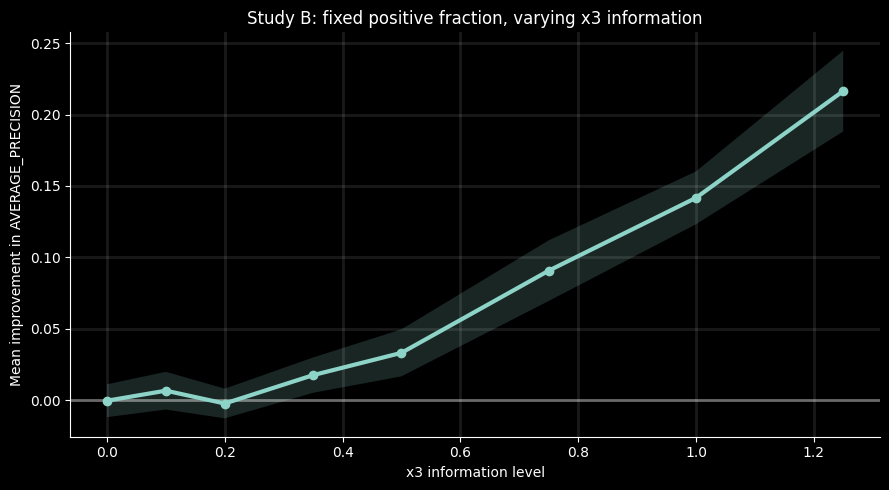

In [41]:
study_B_improvements, study_B_summary = runner.run_study_B_x3_information()

display(study_B_summary.round(5))

plot_study_summary_inline(
    summary=study_B_summary,
    x_col="x3 information level",
    title="Study B: fixed positive fraction, varying x3 information",
    primary_metric=CONFIG["primary_metric"],
)

runner.plot_study_summary(
    summary=study_B_summary,
    x_col="x3 information level",
    title="Study B: fixed positive fraction, varying x3 information",
    filename="study_B_x3_information.png",
)

## 7. Artifacts

All CSV/PNG/JSON outputs land in `artifacts_info_studies/`.

In [27]:
output_dir = Path(CONFIG["output_dir"])
sorted(p.name for p in output_dir.glob("*"))

['config_snapshot.json',
 'study_A_improvements.csv',
 'study_A_positive_fraction.png',
 'study_A_raw_scores.csv',
 'study_A_summary.csv',
 'study_B_improvements.csv',
 'study_B_raw_scores.csv',
 'study_B_summary.csv',
 'study_B_x3_information.png']